# Домашнее задание 7

**Цель:** Написать парсер для сбора данных с сайта, обработать тексты отзывов IMDB с помощью TF-IDF конфигурации и построить логистическую регрессию для анализа тональности текста.

### Часть 1. Парсинг
Парсим сайт http://quotes.toscrape.com/. Он содержит текстовое описание - цитату и автора и теги.

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

class QuotesParser:
    def __init__(self, base_url, max_pages=5):
        self.base_url = base_url
        self.max_pages = max_pages
        self.data = []

    def parse(self):
        print("Запуск парсера...")
        for page in range(1, self.max_pages + 1):
            url = f"{self.base_url}/page/{page}/"
            print(f"Парсинг страницы: {url}")
            
            try:
                response = requests.get(url, timeout=10)
                if response.status_code != 200:
                    break
                
                soup = BeautifulSoup(response.text, 'html.parser')
                quotes = soup.find_all('div', class_='quote')
                
                if not quotes:
                    break
                    
                for quote in quotes:
                    text = quote.find('span', class_='text').text
                    author = quote.find('small', class_='author').text
                    tags = [tag.text for tag in quote.find_all('a', class_='tag')]
                    
                    self.data.append({
                        'text': text,
                        'author': author,
                        'tags_count': len(tags)
                    })
                    
            except Exception as e:
                print(f"Ошибка при парсинге страницы {page}: {e}")
                break

            time.sleep(0.3)
            
        print(f"Парсинг завершен. Собрано объектов: {len(self.data)}")
        return pd.DataFrame(self.data)

parser = QuotesParser(base_url="http://quotes.toscrape.com", max_pages=10)
df_parsed = parser.parse()
display(df_parsed.head())
df_parsed.to_csv('parsed_quotes.csv', index=False)

Запуск парсера...
Парсинг страницы: http://quotes.toscrape.com/page/1/
Парсинг страницы: http://quotes.toscrape.com/page/2/
Парсинг страницы: http://quotes.toscrape.com/page/3/
Парсинг страницы: http://quotes.toscrape.com/page/4/
Парсинг страницы: http://quotes.toscrape.com/page/5/
Парсинг страницы: http://quotes.toscrape.com/page/6/
Парсинг страницы: http://quotes.toscrape.com/page/7/
Парсинг страницы: http://quotes.toscrape.com/page/8/
Парсинг страницы: http://quotes.toscrape.com/page/9/
Парсинг страницы: http://quotes.toscrape.com/page/10/
Парсинг завершен. Собрано объектов: 100


,text,author,tags_count
0,“The world as we have created it is a process ...,Albert Einstein,4
1,"“It is our choices, Harry, that show what we t...",J.K. Rowling,2
2,“There are only two ways to live your life. On...,Albert Einstein,5
3,"“The person, be it gentleman or lady, who has ...",Jane Austen,4
4,"“Imperfection is beauty, madness is genius and...",Marilyn Monroe,2


### Часть 2. NLP
Рабобтаем датасетом IMDB. Предсказываем оценку отзыва: positive или negative

In [3]:
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv('IMDB Dataset.csv')
print(f"Размер датасета IMDB: {df.shape}")

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<br\s*/?>', ' ', text) # убираем html-теги переноса строки
    text = re.sub(r'[^a-zA-Z\s]', '', text) # оставляем только буквы
    return text

df['clean_review'] = df['review'].apply(clean_text)

# Кодируем целевую переменную в 0 и 1
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})
display(df[['clean_review', 'sentiment']].head())

Размер датасета IMDB: (50000, 2)


,clean_review,sentiment
0,one of the other reviewers has mentioned that ...,1
1,a wonderful little production the filming te...,1
2,i thought this was a wonderful way to spend ti...,1
3,basically theres a family where a little boy j...,0
4,petter matteis love in the time of money is a ...,1


#### Разбиение данных и TF-IDF трансформация

In [4]:
# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_review'], df['sentiment'], test_size=0.3, random_state=42, stratify=df['sentiment']
)

# Настройка TF-IDF по требованиям ТЗ
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),    # отдельные токены и биграммы
    stop_words='english',  # отсеиваем английские стоп-слова
    min_df=5,              # отсеиваем слишком редкие слова
    max_df=0.8,            # отсеиваем слишком частые слова
    norm=None              # ВАЖНО: отключаем l2 регуляризацию нормализации векторов
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Количество извлеченных признаков (слов/биграмм): {X_train_tfidf.shape}")

Количество извлеченных признаков (слов/биграмм): (35000, 104558)


#### Обучение модели и оценка качества

In [5]:
# Подбор параметра регуляризации
best_c = 1.0
best_acc = 0.0

for c_param in [0.0001, 0.001, 0.01, 0.1]:
    clf = LogisticRegression(C=c_param, max_iter=1000, random_state=42, solver='saga')
    clf.fit(X_train_tfidf, y_train)
    preds = clf.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds)
    print(f"Параметр регуляризации C={c_param} | Accuracy на тесте: {acc:.4f}")
    if acc > best_acc:
        best_acc = acc
        best_c = c_param

# Обучаем лучшую модель
print(f"Обучение финальной модели с C={best_c}...")
final_model = LogisticRegression(C=best_c, max_iter=1000, random_state=42, solver='saga')
final_model.fit(X_train_tfidf, y_train)

final_preds = final_model.predict(X_test_tfidf)
print("Метрики качества итоговой модели:")
print(classification_report(y_test, final_preds, target_names=['Negative', 'Positive']))

Параметр регуляризации C=0.0001 | Accuracy на тесте: 0.8919
Параметр регуляризации C=0.001 | Accuracy на тесте: 0.9053
Параметр регуляризации C=0.01 | Accuracy на тесте: 0.9023


C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Параметр регуляризации C=0.1 | Accuracy на тесте: 0.9010
Обучение финальной модели с C=0.001...
Метрики качества итоговой модели:
              precision    recall  f1-score   support

    Negative       0.91      0.90      0.90      7500
    Positive       0.90      0.91      0.91      7500

    accuracy                           0.91     15000
   macro avg       0.91      0.91      0.91     15000
weighted avg       0.91      0.91      0.91     15000



#### Визуализация коэффициентов регрессии

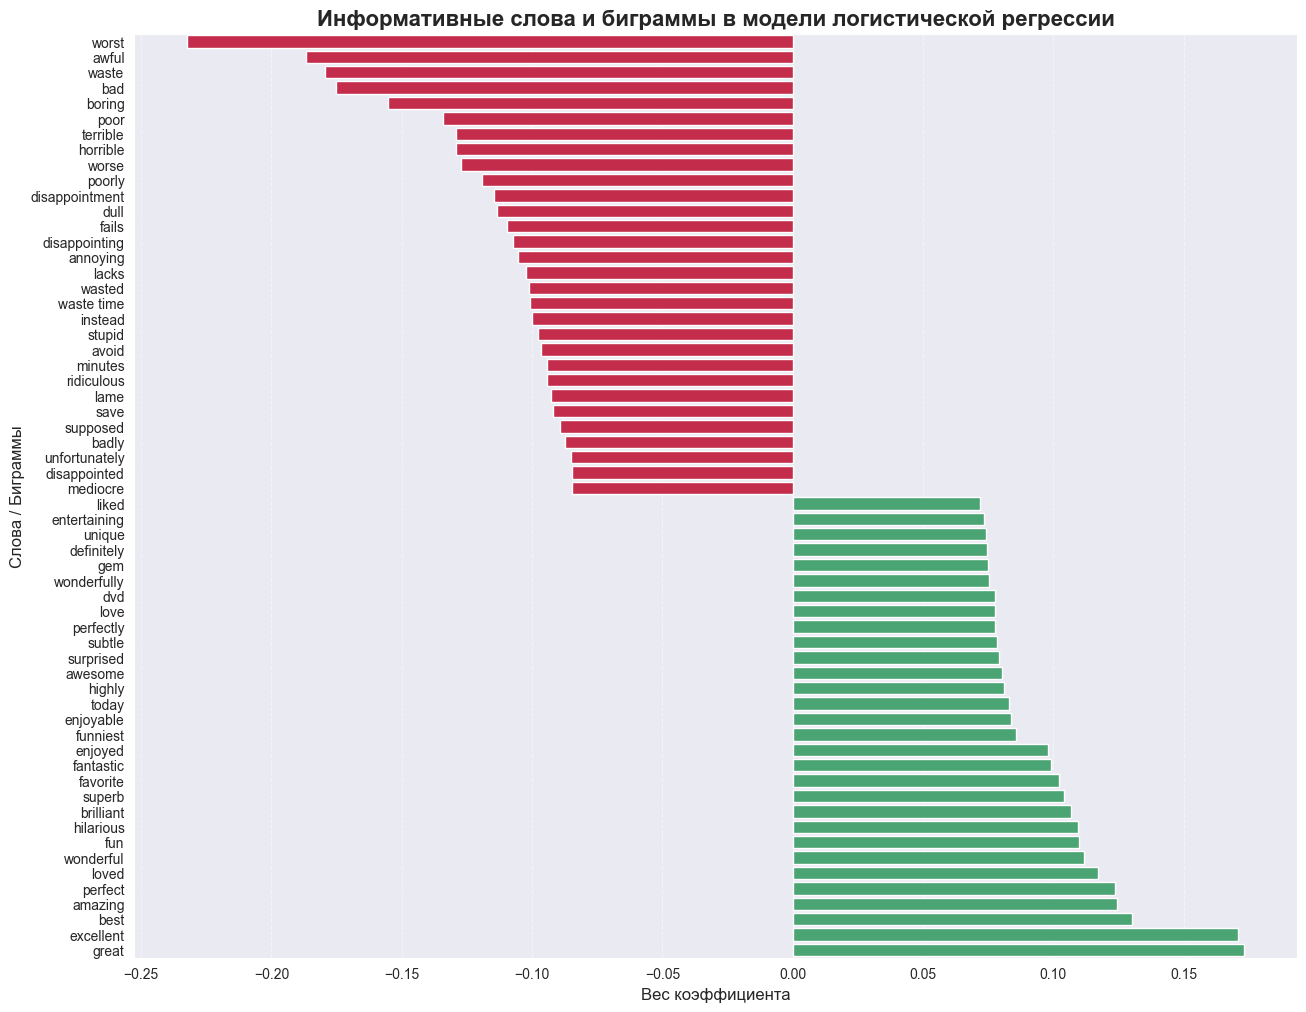

In [9]:
feature_names = np.array(vectorizer.get_feature_names_out())
coefficients = final_model.coef_[0]

sorted_indices = np.argsort(coefficients)

negative_indices = sorted_indices[:30]
positive_indices = sorted_indices[-30:]
indices = np.hstack([negative_indices, positive_indices])

features = feature_names[indices]
coefficients = coefficients[indices]

plt.figure(figsize=(15, 12))
colors = ['crimson' if c < 0 else 'mediumseagreen' for c in coefficients]
sns.barplot(x=coefficients, y=features, hue=features, palette=colors, legend=False)
plt.title('Информативные слова и биграммы в модели логистической регрессии', fontsize=16, fontweight='bold')
plt.xlabel('Вес коэффициента', fontsize=12)
plt.ylabel('Слова / Биграммы', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

### Выводы:

Тексты отзывов были преобразованы в матрицу признаков размером 35 000 строк на 104 558 уникальных слов и биграмм.

Построенная логистическая регрессия на признаках TF-IDF (с использованием униграмм и биграмм без L2-нормализации векторов) демонстрирует высокую точность предсказания: Accuracy = 0.91 (91% правильных ответов). Метрики precision, recall и f1-score для обоих классов (Positive/Negative) стабильно удерживают планку 0.90 – 0.91.

Интерпретация признаков:

Положительные маркеры: Наибольший вклад в класс Positive вносят слова excellent, best, amazing, perfect.

Отрицательные маркеры: Наибольший вклад в класс Negative вносят слова worst, awful, waste, bad, boring.

Включение биграмм ngram_range=(1, 2) помогло модели уловить контекстные словосочетания, которые точнее передают эмоциональную окраску, чем отдельные слова, размывающиеся в общем контексте документа.